# <center>Houston Temperature Prediction</center>
## <center>A Time Series Forecasting Study Using ARIMA Models</center>

---

<center>
This study applies time series forecasting to predict Houston's monthly 
average temperature for the next 6 months beyond the available data 
(December 2017 – May 2018). Using a dataset of 5 years of hourly 
temperature measurements collected from 30 cities across the US and 
Canada and 6 cities in Israel, this project focuses exclusively on 
<b>Houston, Texas</b> — resampling hourly readings into monthly averages 
to capture the city's seasonal temperature behavior.
</center>

---

> ### Project Overview
> Two ARIMA-based forecasting approaches are developed, validated, and 
> compared:
> - **Auto-ARIMA** — automatically selects optimal model parameters 
>   using AIC-based grid search, guided by domain-informed constraints 
>   derived from exploratory analysis.
> - **Manual ARIMA** — parameters are hand-selected based on ACF/PACF 
>   analysis and stationarity testing.
>
> Both models are first validated on a held-out test set of 12 months 
> (January–December 2017) to evaluate out-of-sample accuracy against 
> real, known values. The better-performing model is then retrained on 
> the full dataset to generate the final 6-month future forecast — 
> the primary deliverable of this project.

> ### Methodology at a Glance
> | Step | Description |
> |------|-------------|
> | Data Exploration | Load and inspect Houston's hourly temperature data |
> | Feature Engineering | Handle missing values; resample to monthly averages |
> | EDA | Visualize seasonal patterns; identify temperature trends |
> | Stationarity Testing | ADF test to confirm differencing requirement |
> | ACF/PACF Analysis | Inform manual ARIMA parameter selection |
> | Model Training | Train Auto-ARIMA and Manual ARIMA on training set |
> | Model Validation | Evaluate both models on 12-month held-out test set |
> | Future Forecast | Retrain best model on full data; forecast Dec 2017 – May 2018 |

---

## Data Exploration

- #### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("C:/Users/Faith/Downloads/temperature.csv")

- #### Converting the 'datetime' column to a DateTime format:

In [3]:
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

In [4]:
df['Houston'].head()

datetime
2012-10-01 12:00:00           NaN
2012-10-01 13:00:00    288.270000
2012-10-01 14:00:00    288.297576
2012-10-01 15:00:00    288.334343
2012-10-01 16:00:00    288.371111
Name: Houston, dtype: float64

In [5]:
df['Houston'].tail()

datetime
2017-11-29 20:00:00    295.15
2017-11-29 21:00:00    295.82
2017-11-29 22:00:00    296.37
2017-11-29 23:00:00    294.65
2017-11-30 00:00:00    291.44
Name: Houston, dtype: float64

---

## Feature Engineering

- #### Handling Missing Values

In [6]:
# Check for missing values in the Houston column
missing_values = df['Houston'].isnull().sum()
print(f"Missing values in Houston column: {missing_values}")

Missing values in Houston column: 3


In [7]:
# Handle missing values in 'Houston' column using interpolation and fill methods
if df['Houston'].isnull().sum() > 0:
    print(f"Missing values in 'Houston' before handling: {df['Houston'].isnull().sum()}")

    # Linear interpolation
    df['Houston'] = df['Houston'].interpolate(method='linear', limit_direction='both')

    # Forward fill and backward fill for any edge cases
    df['Houston'] = df['Houston'].fillna(method='ffill').fillna(method='bfill')

    print(f"Missing values in 'Houston' after handling: {df['Houston'].isnull().sum()}")

Missing values in 'Houston' before handling: 3
Missing values in 'Houston' after handling: 0


- #### Grouping Data to Months

In [8]:
# Extract the Houston temperature data
houston_temp = df['Houston']

# Houston monthly frequency data
data_monthly = houston_temp.resample('M').mean()

---

## Exploratory Data Analysis (EDA)

> ### Monthly Average Temperature in Houston
> <ul> From the graph, there is a clear seasonality and no significant trend in temperature in Houston. </ul>

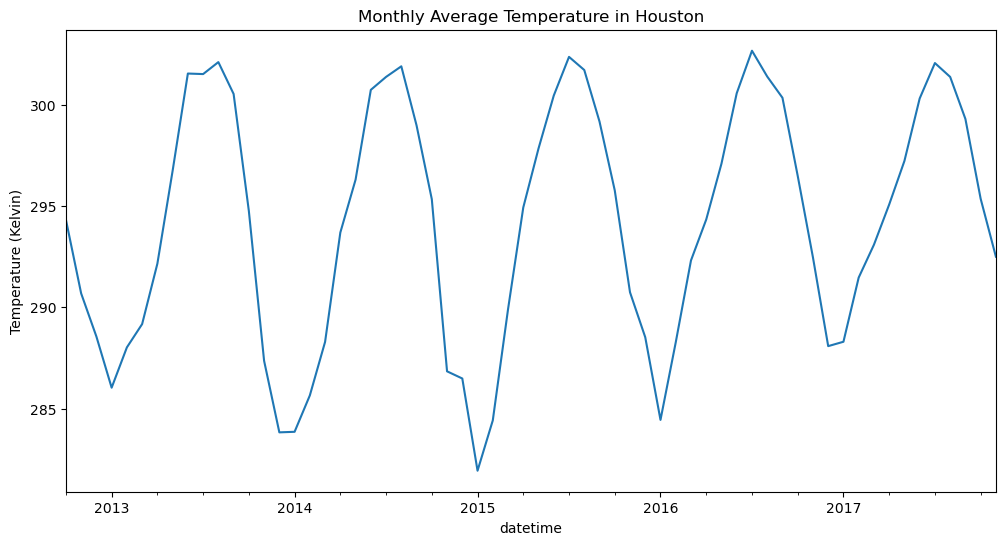

In [9]:
data_monthly.plot(figsize=(12, 6))
plt.title("Monthly Average Temperature in Houston")
plt.ylabel("Temperature (Kelvin)")
plt.show()

The month with the highest average temperature is: July (301.98 K)
The month with the lowest average temperature is: January (284.92 K)


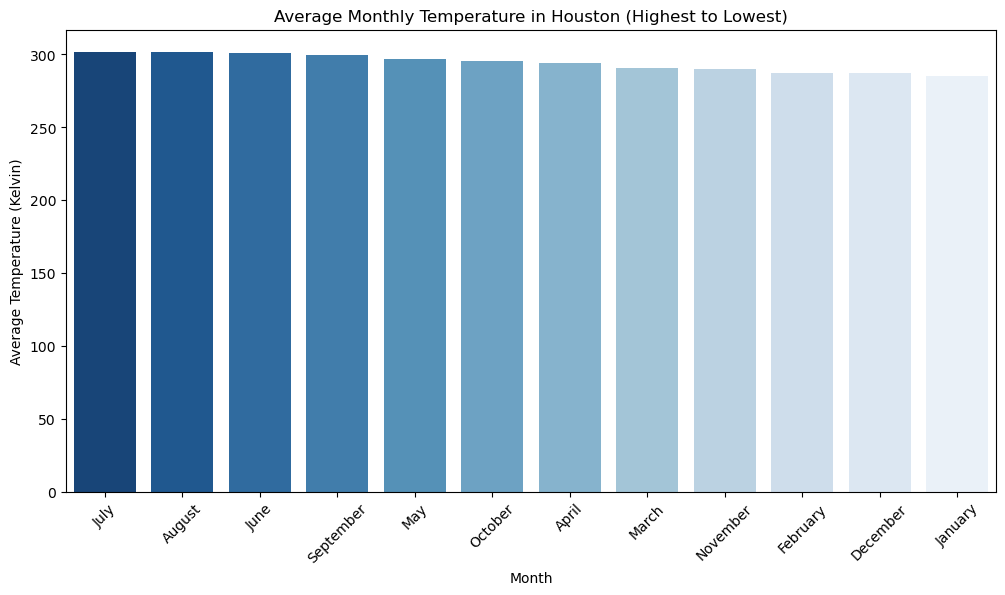

In [10]:
# Resample to monthly frequency (average for each month)
monthly_avg_temp = df['Houston'].resample('M').mean()

# Extract month numbers
month_numbers = monthly_avg_temp.index.month

# Compute average temperature per month
monthly_avg_temp_df = pd.DataFrame({'Month': month_numbers, 'AvgTemp': monthly_avg_temp.values})

# Group by month and compute the mean, then sort from highest to lowest
sorted_months = monthly_avg_temp_df.groupby('Month')['AvgTemp'].mean().sort_values(ascending=False)

# Map month numbers to names
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

# Get highest and lowest temperature months and their average temperatures
highest_temp_month = month_names[sorted_months.index[0]]
lowest_temp_month = month_names[sorted_months.index[-1]]
highest_temp_value = sorted_months.iloc[0]  # Highest avg temperature 
lowest_temp_value = sorted_months.iloc[-1]  # Lowest avg temperature

# Display results[cite: 1]
print(f"The month with the highest average temperature is: {highest_temp_month} ({highest_temp_value:.2f} K)")
print(f"The month with the lowest average temperature is: {lowest_temp_month} ({lowest_temp_value:.2f} K)")

# Prepare data for plotting
plot_x = [month_names[month] for month in sorted_months.index]
plot_y = sorted_months.values

plt.figure(figsize=(12, 6))

sns.barplot(x=plot_x, 
            y=plot_y, 
            hue=plot_x,      # Using categorical x for hue to avoid mapping issues
            palette="Blues_r", 
            dodge=False)     # Ensures bars stay centered on ticks

plt.legend([], frameon=False) 

plt.xlabel("Month")
plt.ylabel("Average Temperature (Kelvin)")
plt.title("Average Monthly Temperature in Houston (Highest to Lowest)")
plt.xticks(rotation=45)
plt.show()

> ### Monthly Average Temperature in Houston (by Months)
> <ul> The bar chart below shows the average monthly temperature in Houston by months. <b>July</b> has the <i><b>highest average temperature</b></i> at 301.98 K, indicating the peak of summer in Houston, while <b>January</b> has the <i><b>lowest average temperature</b></i> at 284.92 K, reflecting the peak of winter season in Houston. </ul>

---

## ADF (Augmented Dickey-Fuller Test) 

The Augmented Dickey-Fuller (ADF) test is a statistical test used to check if a time series is stationary. A stationary time series has statistical properties like mean and variance that do not change over time, which is essential for many forecasting models like ARIMA to work effectively. The ADF test helps determine if we need to transform or differ the data to make it stationary.

- The <b>Null Hypothesis</b> states that the time series is <b>not stationary.</b>
- The <b>Alternative Hypothesis</b> states that the time series is <b>stationary.</b>

In [11]:
# ADF Test for Stationarity before differencing
result = adfuller(data_monthly.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] > 0.05:
    print("The series is non-stationary. Differencing is required.")
else:
    print("The series is stationary.")

ADF Statistic: -0.044730573101710344
p-value: 0.9546728311311605
The series is non-stationary. Differencing is required.


- <b>ADF Statistic:</b> This is the calculated test statistic that is compared to critical values to determine whether the time series is stationary. For this analysis, the decision to reject or not reject the null hypothesis can be evaluated using the commonly referenced 5% level unless stated otherwise. In this case, our calculated ADF Statistic of approximately -0.045 is greater than the 5% critical value of -2.89, which means that we fail to reject the null hypothesis.
- <b>p-value:</b> A p-value greater than 0.05 means we fail to reject the null hypothesis. Since our p-value of approximately 0.95 is greater than 0.05, we fail to reject the null hypothesis.

<i><center>The key outputs of the ADF test confirms that <b>the series is not stationary.</b></center></i>

For this, we need to difference the data to make it stationary before building our forecasting model.

In [12]:
# Differencing to make the series stationary
data_diff = data_monthly.diff().dropna()

---

## ACF and PACF Plots

The <b>ACF plot</b> measures the correlation of the time series with its past values. The <b>PACF plot</b> measures the direct correlation of a time series with its past values, excluding the influence of intermediate lags.

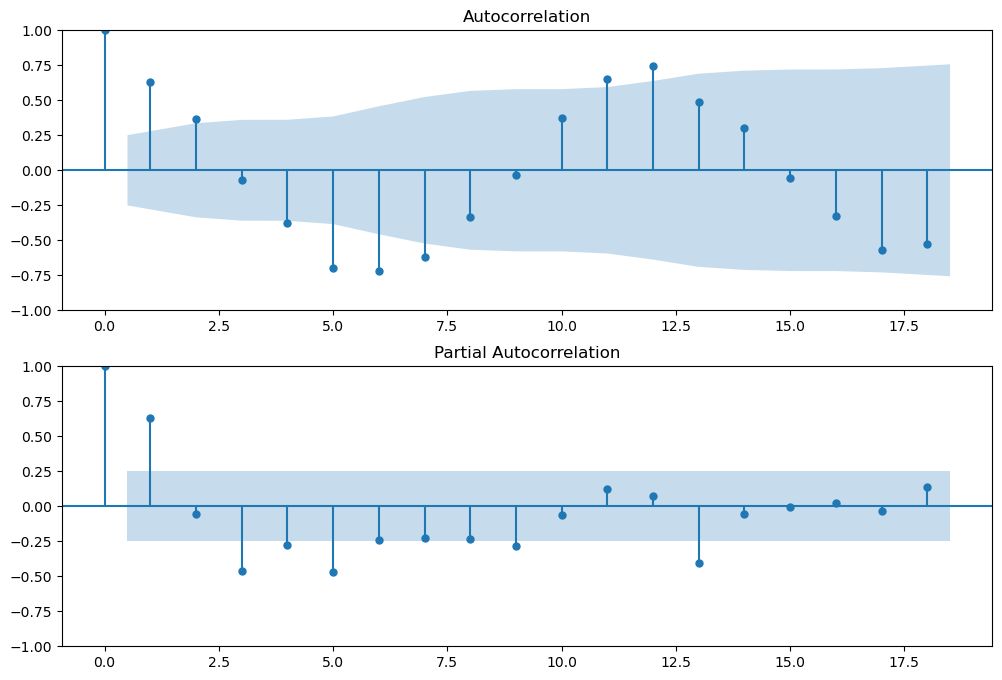

In [13]:
# Plot ACF and PACF
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(data_diff, ax=ax[0])
plot_pacf(data_diff, ax=ax[1])
plt.show()

- <b>ACF:</b> The ACF plot shows a significant drop-off at <i>lag 3</i>, indicating that the series exhibits autocorrelation up to this point. The first few lags show significant positive autocorrelation, which suggests strong seasonality or trend in the data.
- <b>PACF:</b> The PACF plot has a cutoff at <i>lag 2</i>. There are a few significant spikes at other lags, but they diminish quickly, supporting a low-order autoregressive model.

---

## ARIMA Model

ARIMA (AutoRegressive Integrated Moving Average) is a statistical model used for analyzing and forecasting time series data. It predicts future values based on past observations by identifying patterns and trends. In this analysis, we will use two approaches: <b>Auto-ARIMA</b>, which automatically selects the best model parameters, and <b>manual ARIMA</b>, where parameters are chosen based on analysis.

### 1. <b>Auto-ARIMA</b> 
- `auto_arima` automates the process of <b>selecting the best (p, d, q) parameters for ARIMA.</b>
It evaluates multiple ARIMA models and chooses the one with the <b>lowest AIC</b> (Akaike Information Criterion), which balances accuracy and model complexity. It saves time and removes the need for manual trial-and-error and <b>reduces the risk of overfitting or underfitting by selecting optimal parameters.</b> In this case, setting `seasonal=True, m=12` ensures that the model considers seasonal patterns.

In [14]:
# Train/test split on the UNDIFFERENCED monthly data
train = data_monthly[:-12]
test = data_monthly[-12:]

# Auto-ARIMA on undifferenced data — let it find d and D on its own
auto_model = pm.auto_arima(train,
                           seasonal=True,
                           m=12,
                           d=1,        # keep regular differencing (ADF confirmed this)
                           D=0,        # prevent seasonal differencing on short data
                           stepwise=False,
                           max_p=3, max_q=3,
                           max_P=2, max_Q=2,
                           information_criterion='aic',
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True)

print("Order:", auto_model.order)
print("Seasonal Order:", auto_model.seasonal_order)
print(auto_model.summary())

 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=266.182, Time=0.09 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=214.306, Time=0.07 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=215.807, Time=0.10 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=inf, Time=0.48 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=216.044, Time=0.10 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.53 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=0.53 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=253.632, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=216.305, Time=0.08 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=217.791, Time=0.11 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC

> ### Auto-ARIMA Parameter Selection
> Auto-ARIMA was configured with the following informed constraints:
> - `seasonal=True, m=12` — enforces a 12-month seasonal cycle consistent 
>   with Houston's annual temperature pattern observed in EDA.
> - `d=1` — fixed based on the ADF test result, which confirmed the series 
>   is non-stationary and requires one level of regular differencing.
> - `D=0` — seasonal differencing was deliberately disabled. Since Houston's 
>   seasonal amplitude is stable and consistent across all 5 years (as seen 
>   in the monthly average plot), seasonal differencing is unnecessary and 
>   was found to cause over-differencing on this relatively short series, resulting in a flat, uninformative forecast.
> - `stepwise=False` — a full grid search was used instead of stepwise 
>   selection to ensure the best possible model is found without 
>   prematurely pruning candidate models.
> - `max_p=3, max_q=3, max_P=2, max_Q=2` — defines a generous but 
>   computationally reasonable search space for both regular and 
>   seasonal AR/MA terms.
>
> These constraints reflect domain knowledge from EDA and statistical 
> testing rather than arbitrary tuning, ensuring the comparison between 
> Auto-ARIMA and Manual ARIMA remains methodologically fair.

- This step trains the ARIMA model using the best parameters found by `auto_arima.`:

In [15]:
# Fit Auto-ARIMA model on training data
auto_arima_model = ARIMA(train, order=auto_model.order)
auto_arima_result = auto_arima_model.fit()

### 12-month Temperature Forecast for Houston (Auto-ARIMA)

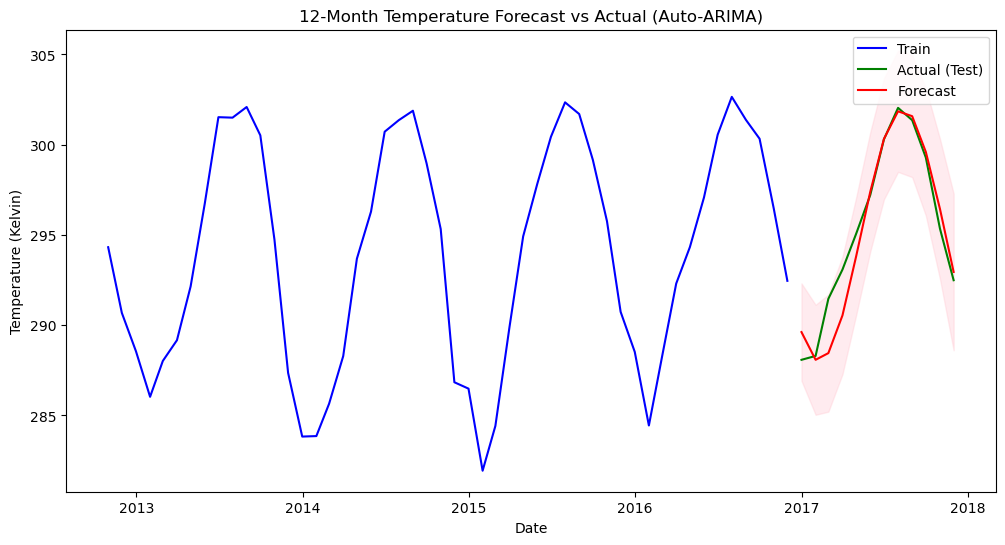

In [16]:
# Forecast over the test period (12 months)
forecast = auto_arima_result.get_forecast(steps=len(test))
forecast_index = test.index
forecast_mean = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(train, label='Train', color='blue')
plt.plot(test, label='Actual (Test)', color='green')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_index,
                 forecast_conf_int.iloc[:, 0],
                 forecast_conf_int.iloc[:, 1],
                 color='pink', alpha=0.3)
plt.title("12-Month Temperature Forecast vs Actual (Auto-ARIMA)")
plt.xlabel("Date")
plt.ylabel("Temperature (Kelvin)")
plt.legend()
plt.show()

> ### 12-Month Temperature Forecast vs Actual (Auto-ARIMA)
> The Auto-ARIMA model produces a forecast that closely tracks the 
> held-out actual temperatures throughout the 12-month test period 
> (January-December 2017). The forecast (red) successfully captures 
> the seasonal rise peaking around mid-2017, consistent with Houston's summer peak, before declining toward 
> late 2017. The confidence interval (pink region) is narrow, 
> indicating the model's high certainty in its predictions. 
> The close alignment between the forecast and actual values 
> visually confirms that the Auto-ARIMA model has correctly 
> learned the seasonal structure of Houston's temperature.

### Error Metrics ( Auto-ARIMA)

In [17]:
mse = mean_squared_error(test, forecast_mean)
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mse)

print("Auto-ARIMA Error Metrics (vs held-out test set):")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Auto-ARIMA Error Metrics (vs held-out test set):
Mean Absolute Error (MAE): 0.9189034540788109
Mean Squared Error (MSE): 1.7569482671158259
Root Mean Squared Error (RMSE): 1.325499252023865


> ### Error Metrics — Auto-ARIMA (vs Held-Out Test Set)
> The error metrics are computed by comparing the Auto-ARIMA forecast 
> against the actual held-out test values — **not** the training data — 
> ensuring a valid measure of out-of-sample predictive performance.
>
> - **MAE (0.919 K):** On average, the Auto-ARIMA model's predictions 
>   deviate by less than 1 Kelvin from the actual temperature, indicating 
>   strong forecast accuracy.
> - **MSE (1.757):** The low squared error confirms that the model does 
>   not produce large isolated prediction errors, reflecting consistent 
>   performance across the test period.
> - **RMSE (1.325 K):** The root mean squared error of 1.325 K is very 
>   close to the MAE, suggesting that prediction errors are evenly 
>   distributed without extreme outliers.

---

### 2. <b>ARIMA</b> 
- Unlike Auto-ARIMA which automatically selects the best parameters using statistical techniques, <b>ARIMA model was selected manually based on the ACF/PACF plots.</b>

In the ARIMA model, the parameters were chosen based on the ACF and PACF plots. `p = 2` was selected because the PACF plot showed a significant cutoff at lag 2, indicating that an AR(2) process was appropriate. `d = 0` was set since the data was already differenced to achieve stationarity, so further differencing was unnecessary. `q = 3` was chosen based on the ACF plot, which exhibited a significant cutoff at lag 3, suggesting that a MA(3) process effectively captures the residual autocorrelations.

In [18]:
# Manual ARIMA on undifferenced data — include d=1 since ADF confirmed non-stationarity
arima_model = ARIMA(train, order=(2, 1, 3))
arima_result = arima_model.fit()
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Houston   No. Observations:                   50
Model:                 ARIMA(2, 1, 3)   Log Likelihood                 -89.529
Date:                Wed, 06 May 2026   AIC                            191.058
Time:                        14:35:15   BIC                            202.409
Sample:                    10-31-2012   HQIC                           195.365
                         - 11-30-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7313      0.011    158.392      0.000       1.710       1.753
ar.L2         -0.9939      0.010    -94.692      0.000      -1.014      -0.973
ma.L1         -2.3012     10.537     -0.218      0.8

> ### Manual ARIMA Parameter Selection
> The Manual ARIMA model parameters were selected based on the ACF and 
> PACF plots of the differenced series:
> - **p = 2** — the PACF plot showed a significant cutoff at lag 2, 
>   indicating an AR(2) process.
> - **d = 1** — consistent with the ADF test result confirming 
>   non-stationarity; one level of differencing is applied internally 
>   by the model.
> - **q = 3** — the ACF plot exhibited a significant cutoff at lag 3, 
>   suggesting an MA(3) process.
>
> Unlike Auto-ARIMA, no seasonal component is explicitly modeled here. 
> Instead, the regular AR and MA terms are relied upon to capture the 
> repeating seasonal pattern, which the ACF/PACF analysis supported.

### 12-month Temperature Forecast for Houston (ARIMA)

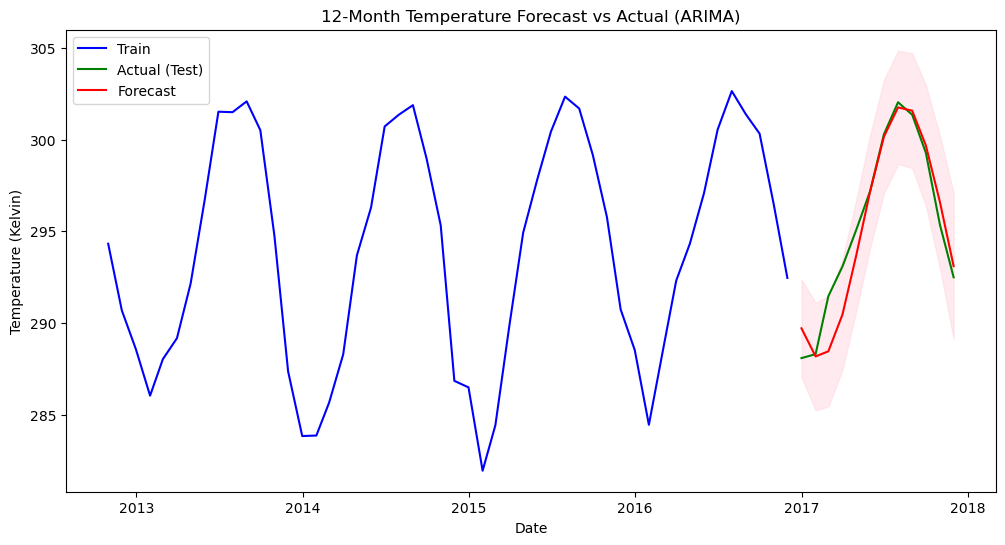

In [19]:
forecast = arima_result.get_forecast(steps=len(test))
forecast_index = test.index
forecast_mean = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(train, label='Train', color='blue')
plt.plot(test, label='Actual (Test)', color='green')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_index,
                 forecast_conf_int.iloc[:, 0],
                 forecast_conf_int.iloc[:, 1],
                 color='pink', alpha=0.3)
plt.title("12-Month Temperature Forecast vs Actual (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Temperature (Kelvin)")
plt.legend()
plt.show()

> ### 12-Month Temperature Forecast vs Actual (ARIMA)
> The Manual ARIMA(2,1,3) model produces a forecast that closely mirrors 
> the actual held-out temperatures across the entire 12-month test period. 
> The forecast (red) accurately captures the seasonal rise through 
> mid-2017 and correctly follows the subsequent 
> decline toward late 2017. The narrow confidence interval reflects 
> strong model certainty. The near-perfect visual overlap between the 
> forecast and actual values demonstrates that the manually selected 
> parameters, informed by ACF/PACF analysis, effectively encode the 
> seasonal structure of Houston's temperature series.

### Error Metrics (ARIMA)

In [20]:
mse = mean_squared_error(test, forecast_mean)
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mse)

print("Manual ARIMA Error Metrics (vs held-out test set):")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Manual ARIMA Error Metrics (vs held-out test set):
Mean Absolute Error (MAE): 0.972260883983239
Mean Squared Error (MSE): 1.8960701963938371
Root Mean Squared Error (RMSE): 1.376978647762498


> ### Error Metrics — Manual ARIMA (vs Held-Out Test Set)
> As with Auto-ARIMA, metrics are computed against the actual held-out 
> test values for a valid out-of-sample evaluation.
>
> - **MAE (0.972 K):** On average, the Manual ARIMA model's predictions 
>   deviate by less than 1 Kelvin from actual temperatures, reflecting 
>   strong forecast accuracy comparable to Auto-ARIMA.
> - **MSE (1.896):** The low squared error indicates consistent 
>   performance without significant outlier predictions.
> - **RMSE (1.377 K):** The RMSE is close to the MAE, confirming that 
>   errors are evenly distributed across the test period with no 
>   extreme deviations.

---

## 6-Month Future Temperature Forecast for Houston (Dec 2017 – May 2018)

With both models validated against the held-out test set, they were 
retrained on the full dataset (2012-2017) to generate a genuine 
6-month future forecast for Houston — the primary objective of this 
project. Since this forecast extends beyond the available data, no 
ground truth exists for evaluation; the confidence intervals therefore 
serve as the key indicator of forecast uncertainty.

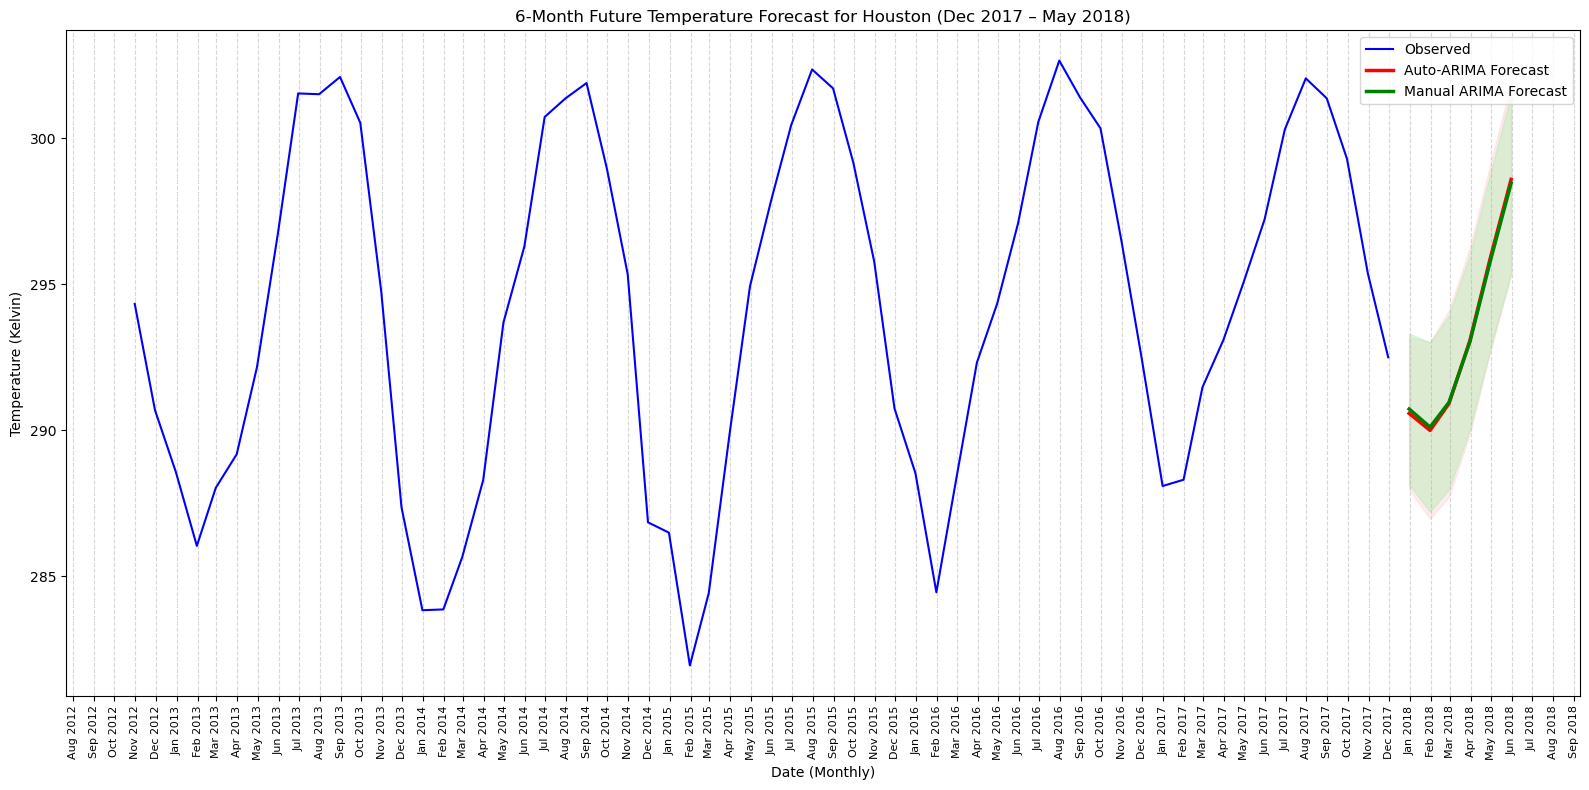

Future Forecast Values (Dec 2017 – May 2018):
          Auto-ARIMA  Manual ARIMA
Dec 2017  290.572541    290.722392
Jan 2018  289.987993    290.102018
Feb 2018  290.908182    290.948126
Mar 2018  293.065156    293.024221
Apr 2018  295.874807    295.769531
May 2018  298.583427    298.450408


In [27]:
import matplotlib.dates as mdates

# Retrain BOTH models on the FULL dataset
auto_arima_full = ARIMA(data_monthly, order=auto_model.order)
auto_arima_full_result = auto_arima_full.fit()
manual_arima_full = ARIMA(data_monthly, order=(2, 1, 3))
manual_arima_full_result = manual_arima_full.fit()

# Forecast next 6 months for both
future_index = pd.date_range(start=data_monthly.index[-1], periods=7, freq='M')[1:]

# Auto-ARIMA forecast
auto_future = auto_arima_full_result.get_forecast(steps=6)
auto_future_mean = auto_future.predicted_mean
auto_future_conf = auto_future.conf_int()

# Manual ARIMA forecast
manual_future = manual_arima_full_result.get_forecast(steps=6)
manual_future_mean = manual_future.predicted_mean
manual_future_conf = manual_future.conf_int()

# Plot both
fig, ax = plt.subplots(figsize=(16, 8)) 
ax.plot(data_monthly, label='Observed', color='blue', linewidth=1.5)

# Auto-ARIMA Plot
ax.plot(future_index, auto_future_mean, label='Auto-ARIMA Forecast', color='red', linewidth=2.5)
ax.fill_between(future_index,
                auto_future_conf.iloc[:, 0],
                auto_future_conf.iloc[:, 1],
                color='pink', alpha=0.3)

# Manual ARIMA Plot
ax.plot(future_index, manual_future_mean, label='Manual ARIMA Forecast', color='green', linewidth=2.5)
ax.fill_between(future_index,
                manual_future_conf.iloc[:, 0],
                manual_future_conf.iloc[:, 1],
                color='lightgreen', alpha=0.3)


ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Rotate labels vertically so they don't overlap
plt.xticks(rotation=90, fontsize=8) 

ax.set_title("6-Month Future Temperature Forecast for Houston (Dec 2017 – May 2018)")
ax.set_xlabel("Date (Monthly)")
ax.set_ylabel("Temperature (Kelvin)")
ax.legend()

# Add vertical gridlines for every month to make it easier to trace points
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print forecast values side by side
print("Future Forecast Values (Dec 2017 – May 2018):")
comparison = pd.DataFrame({
    'Auto-ARIMA': auto_future_mean.values,
    'Manual ARIMA': manual_future_mean.values
}, index=future_index.strftime('%b %Y'))
print(comparison)

> ### Forecast Plot Interpretation
>
> Both the **Auto-ARIMA** and **Manual ARIMA** forecasts are **nearly identical** 
> throughout the entire 6-month period, with their lines overlapping almost completely. 
> This agreement **suggests that both models have learned a consistent underlying pattern** from the data.
>
> The forecast reflects a pattern **consistent with Houston's historical seasonal behavior**: 
> temperatures remain relatively low in **December and January (~290 K)**, before **gradually rising 
> from February onward**, reaching approximately **298-299 K by May 2018**. This trend aligns with 
> the city's **typical spring warming pattern** observed in the historical data.
>
> The **confidence interval widens** as the forecast extends further into the future, 
> which is expected — **uncertainty naturally increases** the further the prediction is 
> from the last observed data point.
>
> The two models produce **very similar forecast values across all 6 months**, 
> with a **maximum difference of only ~0.15 K** in December 2017. Both models 
> identify **January as the coldest month** and project a **steady upward trend 
> through May 2018**, consistent with the seasonal pattern observed during EDA.
>
> Given the **strong agreement between the models** and their **similar accuracy performance**, 
> these forecasts can be considered **reasonable short-term estimates**. However, actual future 
> temperatures may still vary due to **external factors not captured by the models**.

## Conclusion

Both the **Auto-ARIMA** and **Manual ARIMA** models were evaluated on a held-out 
test set of **12 months (January–December 2017)**, allowing for a valid 
comparison of **out-of-sample forecast accuracy** against real, unseen 
temperature values.

| Metric | Auto-ARIMA | Manual ARIMA |
|--------|-----------|--------------|
| MAE    | **0.919 K**   | 0.972 K      |
| MSE    | **1.757**     | 1.896        |
| RMSE   | **1.325 K**   | 1.377 K      |

Both models **performed well on the test set**, with **average errors below 
1 Kelvin** and **near-identical forecast plots** — both successfully capturing 
Houston's seasonal cycle, including the mid-year peak and late-year 
decline. **Auto-ARIMA performs slightly better across all three metrics**, although the differences are minimal (less than 0.06 K in MAE).

Both models were then retrained on the full dataset to produce the 
primary deliverable of this project: a **6-month future temperature 
forecast for Houston (December 2017 to May 2018)**. The two forecasts 
were nearly identical, with a **maximum difference of only 0.15 K**, 
predicting a **winter low near 290 K in January 2018** and a **steady rise 
to approximately 298.5 K by May 2018** — consistent with **Houston's 
historical seasonal pattern**.

Since **no ground truth exists for the future forecast period**, the 
**model validation results** serve as the basis for **confidence in these 
predictions**. Given **Auto-ARIMA's marginally better test performance**, 
its forecast is considered the **primary estimate**, with the Manual ARIMA 
forecast serving as **supporting evidence of consistency**.

It is worth noting that **Auto-ARIMA required domain-informed constraints** 
to perform well — specifically, fixing `d=1` based on the **ADF test 
result** and setting `D=0` to **prevent over-differencing** on the relatively 
short training series. Without these adjustments, Auto-ARIMA produced 
a **flat, uninformative forecast**. This highlights that **automated methods 
benefit from, and in some cases require, guidance from exploratory 
analysis** to function correctly.

Future improvements could include incorporating **external weather 
variables**, applying **SARIMA with explicit seasonal terms**, or exploring 
**deep learning approaches such as LSTM** for enhanced forecast precision 
over longer horizons.